# Plot representative vertical profiles

In [10]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import gsw

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:41411")
client

<Client: 'tcp://127.0.0.1:41411' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

In [56]:
# open FWC dataset
fwc_yrs = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_masked_Beaufort.ZARR')
fwc_yrs = fwc_yrs.fwc_yrs_masked

In [69]:
# Open MLD dataset
mld_ds = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/MLD/MLD_Beaufort_updated.ZARR')
mld_da = mld_ds.mld

In [8]:
def compute_potential_density(SALT_day, THETA_day, ref_lat=70):
    """
    Compute potential density anomaly referenced to 0 dbar.

    Args:
    - SALT_day: DataArray containing salinity (SALT), longitude (XC), and latitude (YC).
    - THETA_day: DataArray containing potential temperature (THETA).
    - ref_lat: Reference latitude for pressure calculation (default is 70°N).

    Returns:
    - sigma0: Potential density anomaly (kg/m³ - 1000).
    """
    # Convert depth (m) to pressure (dbar)
    p = gsw.p_from_z(SALT_day.Z, ref_lat)  # Depth is negative

    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(SALT_day, p, SALT_day.XC, SALT_day.YC)

    # Convert Potential Temperature to Conservative Temperature
    CT = gsw.conversions.CT_from_pt(SA, THETA_day)

    # Calculate potential density anomaly referenced to 0 dbar
    sigma0 = gsw.sigma0(SA, CT)

    # Add metadata
    sigma0.name = 'potential_density'
    sigma0.attrs['long_name'] = 'potential_density'

    return sigma0 + 1000

In [97]:
# calculate potential density from in situ density
sigma = compute_potential_density(SALT_zarr_day.SALT, THETA_zarr_day.THETA, ref_lat=70)

In [98]:
# make depth positive downward
sigma = sigma.assign_coords(Z = sigma.Z * -1)

# subtract 1000
sigma = sigma - 1000

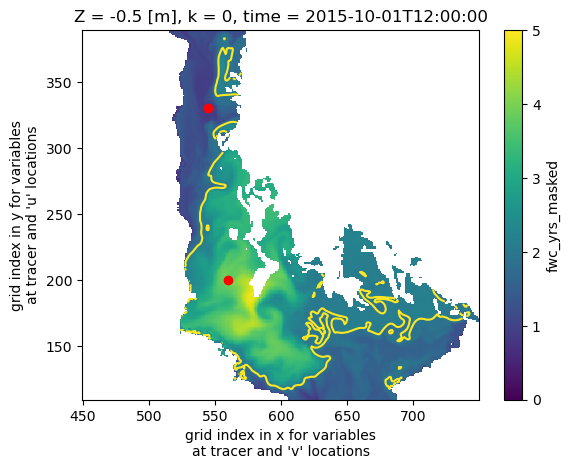

In [66]:
fwc_yrs.sel(time='2015-10-01').plot(vmin=0,vmax=5);
fwc_yrs.sel(time='2015-10-01').isel(time=0).plot.contour(levels=[2])
plt.scatter(545,330,color='r')
plt.scatter(560,200,color='r');

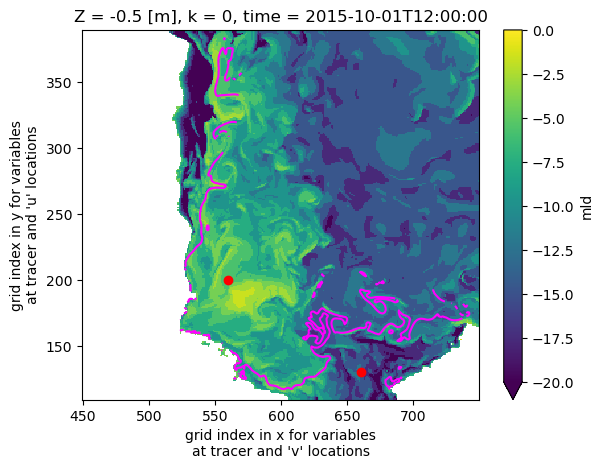

In [77]:
mld_da.sel(time='2015-10-01').plot(vmin=-20,vmax=0);
fwc_yrs.sel(time='2015-10-01').isel(time=0).plot.contour(levels=[2],colors='magenta')
# plt.scatter(545,330,color='r')
plt.scatter(660,130,color='r')
plt.scatter(560,200,color='r');

In [114]:
print(fwc_yrs.sel(time='2015-10-01',i=660,j=130).values)
print(fwc_yrs.sel(time='2015-10-01',i=560,j=200).values)

[1.72329423]
[3.91196673]


In [86]:
sigma.isel(k=9).Z.values

array(-17.705, dtype=float32)

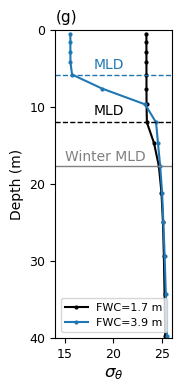

In [138]:
plt.rcParams['font.size'] = 9

fig, ax = plt.subplots(1,1,figsize=[1.5,4])

sigma.sel(time='2015-10-01',i=660,j=130).plot(ax=ax, y='Z',marker='o',color='k',markersize=2,label='FWC=1.7 m');
sigma.sel(time='2015-10-01',i=560,j=200).plot(ax=ax, y='Z',marker='o',color='tab:blue',markersize=2,label='FWC=3.9 m');

# surface MLD
ax.axhline(y=mld_da.sel(time='2015-10-01',i=660,j=130).values*-1,linestyle='dashed',color='k',linewidth=1)
ax.axhline(y=mld_da.sel(time='2015-10-01',i=560,j=200).values*-1,linestyle='dashed',color='tab:blue',linewidth=1)

# winter MLD
ax.axhline(y=sigma.isel(k=9).Z.values,color='gray',linewidth=1)

# add text
ax.text(18,5,'MLD',size=10,color='tab:blue')
ax.text(18,11,'MLD',size=10,color='k')
ax.text(15,17,'Winter MLD',size=10,color='gray')
ax.set_title("")
ax.set_title('(g)',loc='left',size=11)

ax.set_yticks([0,10,20,30,40])

ax.legend(fontsize=8)
ax.set_ylabel("Depth (m)",size=10)
ax.set_xlabel(r"$\sigma_{\theta}$",size=12)
ax.set_ylim(40,0)
ax.set_xlim(14,26);

fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/ex_profiles.png', \
            dpi=300, bbox_inches='tight')